In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv('../data/anonymized_costs.csv')
print("Shape:", df.shape)
df.head()


Shape: (93605, 11)


,InvoiceSectionName,Date,MeterCategory,CostInBillingCurrency,MeterSubCategory,MeterName,SubscriptionName,ResourceGroup,ConsumedService,ResourceLocation,ResourceName
0,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Azure App Service,0.000000,Free Plan,F1 App,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,8e04551db18efa5f0d61d169fc2abbc0a0fe47b337d340...,microsoft.web,westeurope,eb7b2b2291b962a3591cb5284020ee75b4c02937fed01c...
1,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...
2,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.000004,Tables,GRS Data Stored,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,334f28a0945bbab90ebf4a794cac86f5cfe3aacdc42cd2...,Microsoft.Storage,northeurope,b92f8ef6e1ac3ee7ca538e4b03926bbba53e01f1ce6088...
3,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Load Balancer,0.018600,Standard,Standard Included LB Rules and Outbound Rules,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,05a92ef059d22b7847bf97a414cbd9b773f230a341f926...,Microsoft.MachineLearningServices,westeurope,55f17ee5c0235396a7acc69e7fc30d917319e3e053d08e...
4,bc05844fb9454a82a5380ad11fceccc59227e495d31ab1...,12/31/2022,Storage,0.014312,Standard SSD Managed Disks,E2 Disks,95e7dd23f5eed773783fc94e66ed6198d77b9b7c41c51c...,43c17db9ed1b2f8fb2b00a32c6223f6e6b1e4b9b92b5c3...,Microsoft.Compute,northeurope,c97e6c1b0d7cd5a7a56903385811b0a621aa0873089ab8...


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 93605 entries, 0 to 93604
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   InvoiceSectionName     93605 non-null  str    
 1   Date                   93605 non-null  str    
 2   MeterCategory          93605 non-null  str    
 3   CostInBillingCurrency  93605 non-null  float64
 4   MeterSubCategory       93605 non-null  str    
 5   MeterName              93605 non-null  str    
 6   SubscriptionName       93605 non-null  str    
 7   ResourceGroup          93605 non-null  str    
 8   ConsumedService        93605 non-null  str    
 9   ResourceLocation       93605 non-null  str    
 10  ResourceName           93605 non-null  str    
dtypes: float64(1), str(10)
memory usage: 7.9 MB


In [3]:
print("Duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())


Duplicate rows: 20205

Missing values per column:
InvoiceSectionName       0
Date                     0
MeterCategory            0
CostInBillingCurrency    0
MeterSubCategory         0
MeterName                0
SubscriptionName         0
ResourceGroup            0
ConsumedService          0
ResourceLocation         0
ResourceName             0
dtype: int64


In [4]:
df.nunique().sort_values(ascending=False)


CostInBillingCurrency    15057
ResourceName              1615
ResourceGroup              320
MeterName                  219
MeterSubCategory            92
Date                        89
MeterCategory               50
ConsumedService             37
ResourceLocation            12
InvoiceSectionName           1
SubscriptionName             1
dtype: int64

**Observations**

- No missing values in any column.
- There are duplicate rows — likely repeated identical billing line entries — which will be removed during cleaning.
- `InvoiceSectionName` and `SubscriptionName` have only **1 unique value** each → they carry zero predictive signal and will be dropped.
- `ResourceGroup` (320 unique) and `ResourceName` (1,615 unique) are effectively unique identifiers with no generalizable pattern → will be dropped.
- `MeterCategory`, `MeterSubCategory`, `MeterName`, `ConsumedService`, `ResourceLocation` are genuine categorical *features* that describe the service being billed and will be kept.


## Step 3: Exploratory Data Analysis (EDA)

In [5]:
df['CostInBillingCurrency'].describe()


count    93605.000000
mean         0.101932
std          0.465012
min          0.000000
25%          0.000002
50%          0.001696
75%          0.028190
max         26.902857
Name: CostInBillingCurrency, dtype: float64

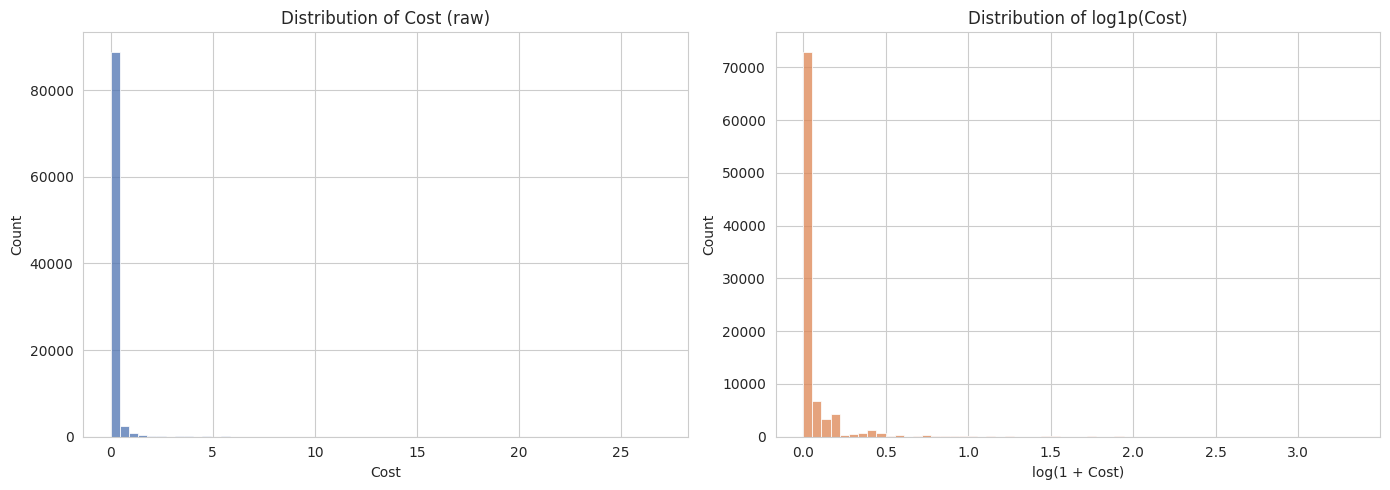

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['CostInBillingCurrency'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Cost (raw)')
axes[0].set_xlabel('Cost')

sns.histplot(np.log1p(df['CostInBillingCurrency']), bins=60, ax=axes[1], color='#DD8452')
axes[1].set_title('Distribution of log1p(Cost)')
axes[1].set_xlabel('log(1 + Cost)')

plt.tight_layout()
plt.savefig('../images/01_cost_distribution.png', dpi=100)
plt.show()


The raw cost distribution is heavily right-skewed — most billing line items cost almost nothing, with a long tail of expensive items. This is typical of cloud usage data (many small metering events, few large ones).

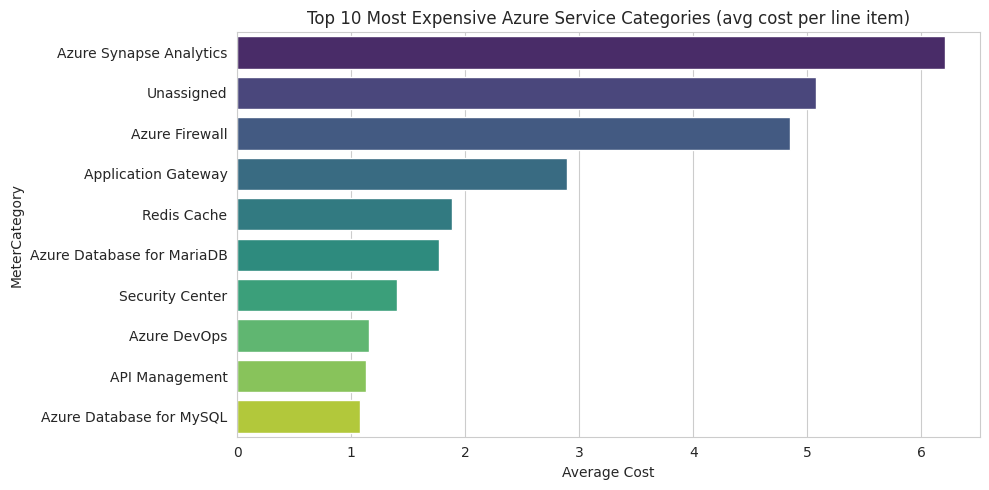

In [7]:
top_expensive = df.groupby('MeterCategory')['CostInBillingCurrency'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_expensive.values, y=top_expensive.index, palette='viridis')
plt.title('Top 10 Most Expensive Azure Service Categories (avg cost per line item)')
plt.xlabel('Average Cost')
plt.tight_layout()
plt.savefig('../images/02_top_expensive_categories.png', dpi=100)
plt.show()


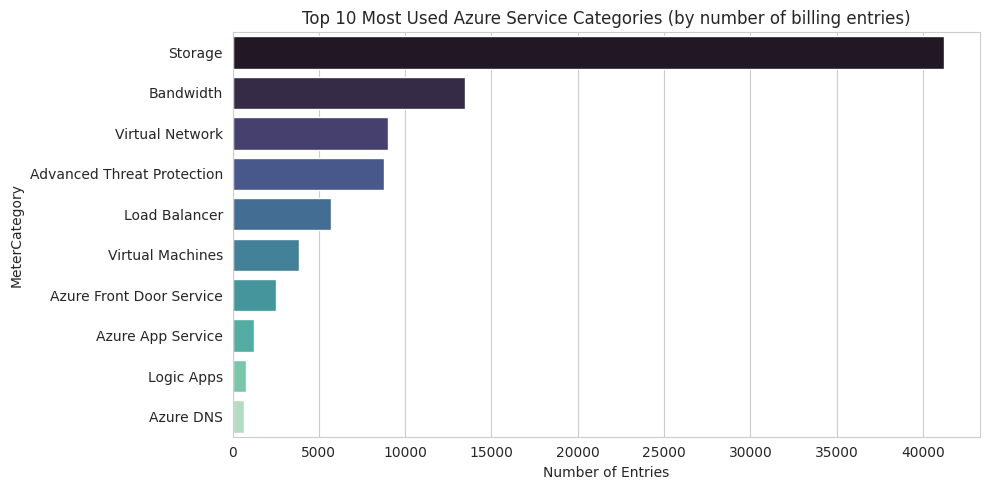

In [8]:
most_used = df['MeterCategory'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=most_used.values, y=most_used.index, palette='mako')
plt.title('Top 10 Most Used Azure Service Categories (by number of billing entries)')
plt.xlabel('Number of Entries')
plt.tight_layout()
plt.savefig('../images/03_most_used_categories.png', dpi=100)
plt.show()


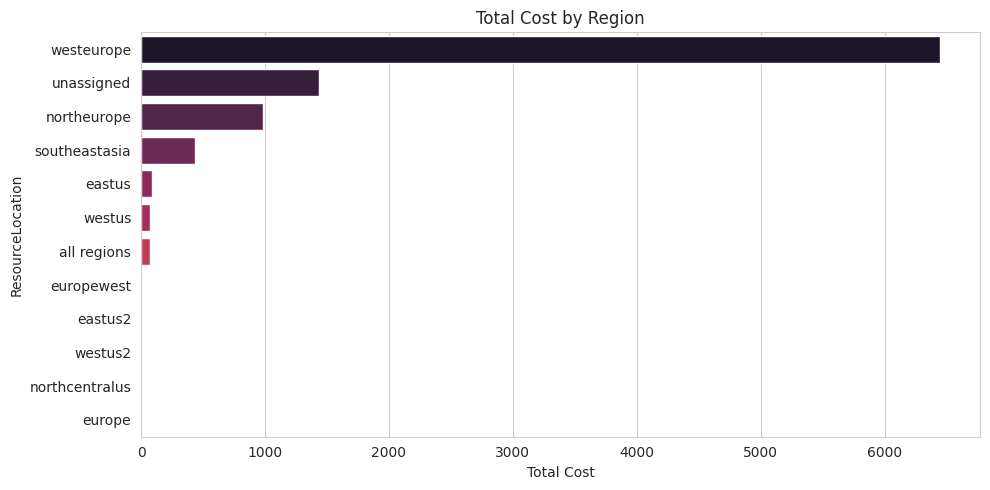

In [9]:
# Normalize casing before this analysis so 'westeurope' and 'WestEurope' aren't counted separately
region_cost = df.assign(ResourceLocation=df['ResourceLocation'].str.lower()).groupby('ResourceLocation')['CostInBillingCurrency'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=region_cost.values, y=region_cost.index, palette='rocket')
plt.title('Total Cost by Region')
plt.xlabel('Total Cost')
plt.tight_layout()
plt.savefig('../images/04_cost_by_region.png', dpi=100)
plt.show()


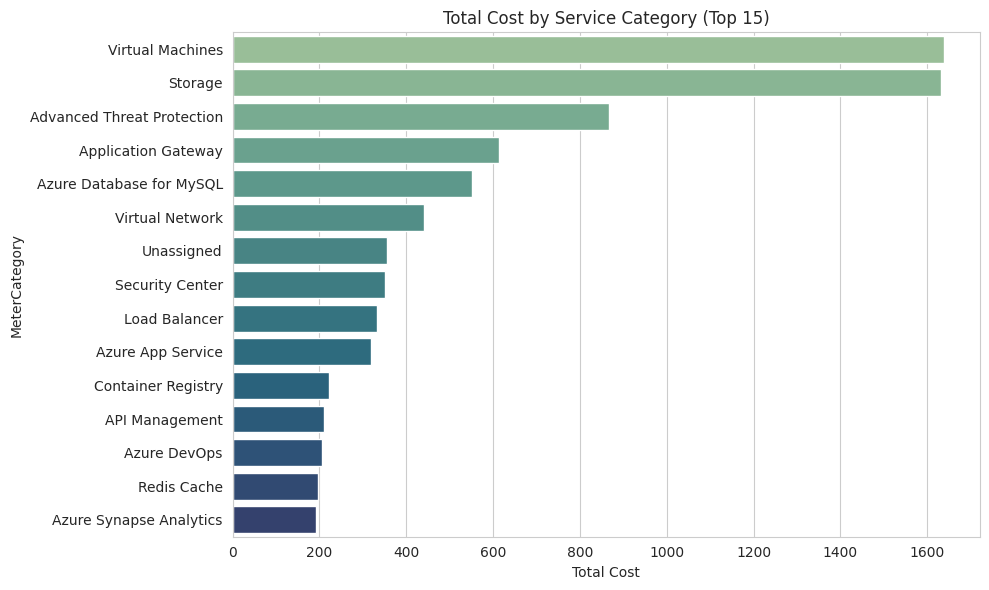

In [10]:
category_cost = df.groupby('MeterCategory')['CostInBillingCurrency'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_cost.values, y=category_cost.index, palette='crest')
plt.title('Total Cost by Service Category (Top 15)')
plt.xlabel('Total Cost')
plt.tight_layout()
plt.savefig('../images/05_total_cost_by_category.png', dpi=100)
plt.show()


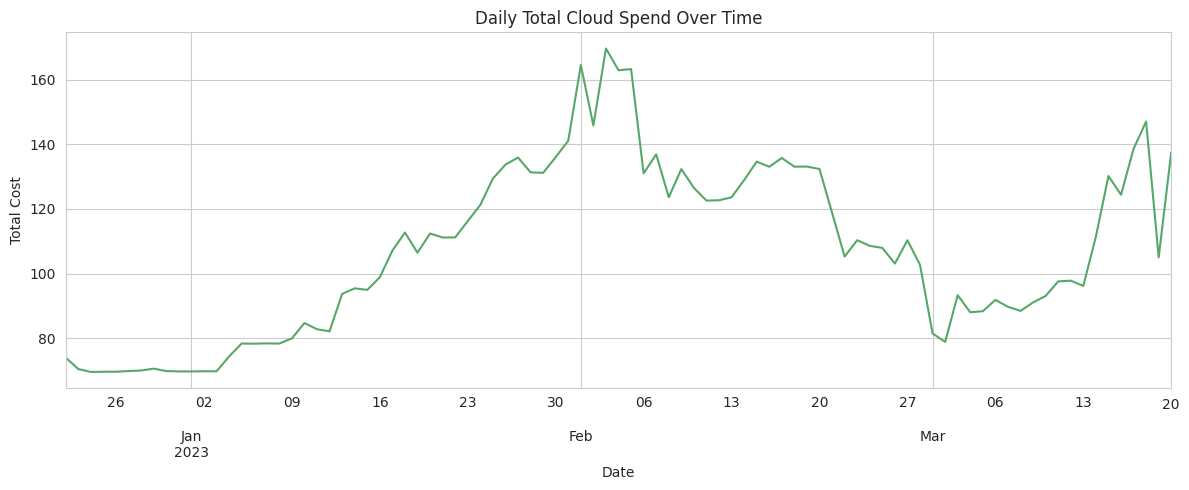

In [11]:
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
monthly = df.set_index('Date_parsed').resample('D')['CostInBillingCurrency'].sum()

plt.figure(figsize=(12, 5))
monthly.plot(color='#55A868')
plt.title('Daily Total Cloud Spend Over Time')
plt.ylabel('Total Cost')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../images/06_daily_spend_trend.png', dpi=100)
plt.show()


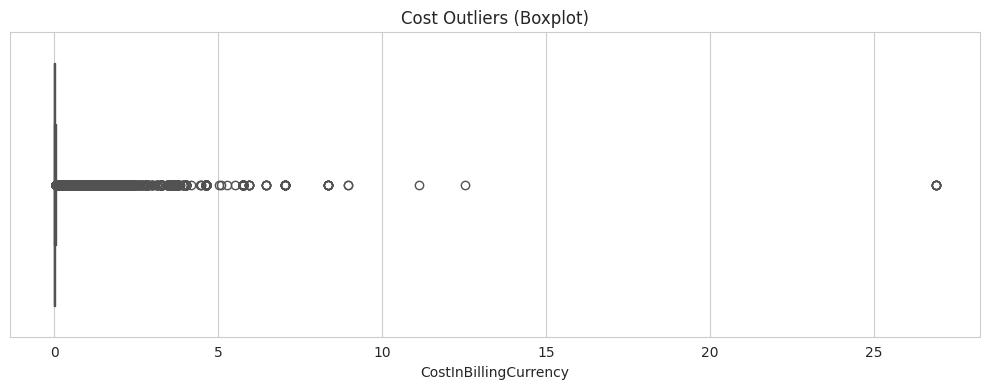

Upper fence (IQR method): 0.0705
Rows above upper fence: 17682 (18.89%)


In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['CostInBillingCurrency'], color='#C44E52')
plt.title('Cost Outliers (Boxplot)')
plt.tight_layout()
plt.savefig('../images/07_cost_outliers.png', dpi=100)
plt.show()

q1, q3 = df['CostInBillingCurrency'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
print(f"Upper fence (IQR method): {upper_fence:.4f}")
print(f"Rows above upper fence: {(df['CostInBillingCurrency'] > upper_fence).sum()} ({(df['CostInBillingCurrency'] > upper_fence).mean()*100:.2f}%)")


There are many statistical outliers by the IQR rule, but they are **legitimate expensive billing events** (e.g. large VM or ML training jobs), not data errors — so they are kept rather than removed. Predicting these correctly is actually the more valuable part of the business problem.

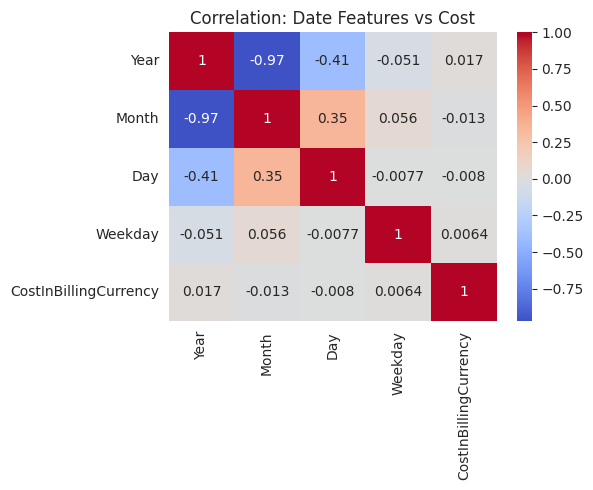

In [13]:
# Correlation among engineered numeric/date features (categorical correlation isn't meaningful pre-encoding)
df['Year'] = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month
df['Day'] = df['Date_parsed'].dt.day
df['Weekday'] = df['Date_parsed'].dt.weekday

corr = df[['Year', 'Month', 'Day', 'Weekday', 'CostInBillingCurrency']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Date Features vs Cost')
plt.tight_layout()
plt.savefig('../images/08_correlation_heatmap.png', dpi=100)
plt.show()


Date-derived features show weak linear correlation with cost individually — cost is driven far more by *which service* is being billed than *when*. The categorical service/region features will carry most of the predictive power.

## Step 4: Data Cleaning

In [14]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows -> new shape: {df.shape}")


Dropped 20205 duplicate rows -> new shape: (73400, 16)


In [15]:
# Fix inconsistent casing found during EDA (e.g. 'Microsoft.Storage' vs 'microsoft.storage', 'WestEurope' vs 'westeurope')
for col in ['ConsumedService', 'ResourceLocation', 'MeterCategory', 'MeterSubCategory', 'MeterName']:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("Unique ConsumedService values after cleaning:", df['ConsumedService'].nunique())
print("Unique ResourceLocation values after cleaning:", df['ResourceLocation'].nunique())


Unique ConsumedService values after cleaning: 33
Unique ResourceLocation values after cleaning: 12


In [16]:
# Date already parsed as Date_parsed above; confirm dtype and no bad parses
print(df['Date_parsed'].dtype)
print("Any NaT after parsing:", df['Date_parsed'].isna().sum())


datetime64[us]
Any NaT after parsing: 0


## Step 5: Feature Engineering

`Year`, `Month`, `Day`, `Weekday` were already derived from `Date` above (needed for the correlation check). We keep them and drop the raw `Date` / `Date_parsed` columns.

In [17]:
df = df.drop(columns=['Date', 'Date_parsed'])
df[['Year', 'Month', 'Day', 'Weekday']].describe()


,Year,Month,Day,Weekday
count,73400.000000,73400.000000,73400.000000,73400.000000
mean,2022.913120,2.750531,15.635940,2.958202
std,0.281661,2.944615,8.551003,1.988625
min,2022.000000,1.000000,1.000000,0.000000
25%,2023.000000,1.000000,8.000000,1.000000
50%,2023.000000,2.000000,16.000000,3.000000
75%,2023.000000,3.000000,23.000000,5.000000
max,2023.000000,12.000000,31.000000,6.000000


## Step 6 & 7: Feature Selection and Encoding

**Dropped (pure identifiers / zero-variance / not learnable patterns):**
- `InvoiceSectionName` — constant (1 unique value)
- `SubscriptionName` — constant (1 unique value)
- `ResourceGroup` — 320 unique values, effectively an ID
- `ResourceName` — 1,615 unique values, effectively an ID

**One-Hot Encoded** (low cardinality, meaningful categories the model can generalize across):
- `MeterCategory`, `ConsumedService`, `ResourceLocation`

**Ordinal / Label Encoded** (higher cardinality — one-hot would create hundreds of sparse columns):
- `MeterSubCategory`, `MeterName`

Rather than doing this encoding manually with `pd.get_dummies` (which is fragile — the app's input columns can silently drift out of sync with the training columns), we wrap all preprocessing in a single scikit-learn `ColumnTransformer` + `Pipeline`. This guarantees the Streamlit app applies **exactly** the same transformation used during training, with unseen categories handled gracefully instead of crashing.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

id_cols = ['InvoiceSectionName', 'SubscriptionName', 'ResourceGroup', 'ResourceName']
df_model = df.drop(columns=id_cols)

target = 'CostInBillingCurrency'
numeric_features = ['Year', 'Month', 'Day', 'Weekday']
onehot_features = ['MeterCategory', 'ConsumedService', 'ResourceLocation']
ordinal_features = ['MeterSubCategory', 'MeterName']

X = df_model.drop(columns=[target])
y = df_model[target]

X.head()


,MeterCategory,MeterSubCategory,MeterName,ConsumedService,ResourceLocation,Year,Month,Day,Weekday
0,azure app service,free plan,f1 app,microsoft.web,westeurope,2022,12,31,5
1,load balancer,standard,standard included lb rules and outbound rules,microsoft.machinelearningservices,westeurope,2022,12,31,5
2,storage,tables,grs data stored,microsoft.storage,northeurope,2022,12,31,5
3,storage,standard ssd managed disks,e2 disks,microsoft.compute,northeurope,2022,12,31,5
4,storage,standard ssd managed disks,e2 disks,microsoft.compute,northeurope,2022,12,30,4


## Step 8: Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (58720, 9)
Test shape: (14680, 9)


## Step 9: Feature Scaling & Preprocessing Pipeline

`StandardScaler` is applied to the numeric date features. One-hot and ordinal encoders handle the categorical columns. All three are combined in a single `ColumnTransformer`, fit **only on training data** to avoid data leakage.

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_features),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Step 10: Model Training — Linear Regression

In [21]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_pipeline.fit(X_train, y_train)
print("Model trained.")


Model trained.


## Step 11: Prediction

In [22]:
y_pred = model_pipeline.predict(X_test)
y_pred[:10]


array([ 0.11377084, -0.03347997, -0.03153686,  0.14825265,  0.11832902,
        0.24971041, -0.01509647,  0.04044268,  0.02486177,  0.11249992])

## Step 12: Model Evaluation

In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R2   : {r2:.6f}")


MAE  : 0.105780
MSE  : 0.094153
RMSE : 0.306844
R2   : 0.458816


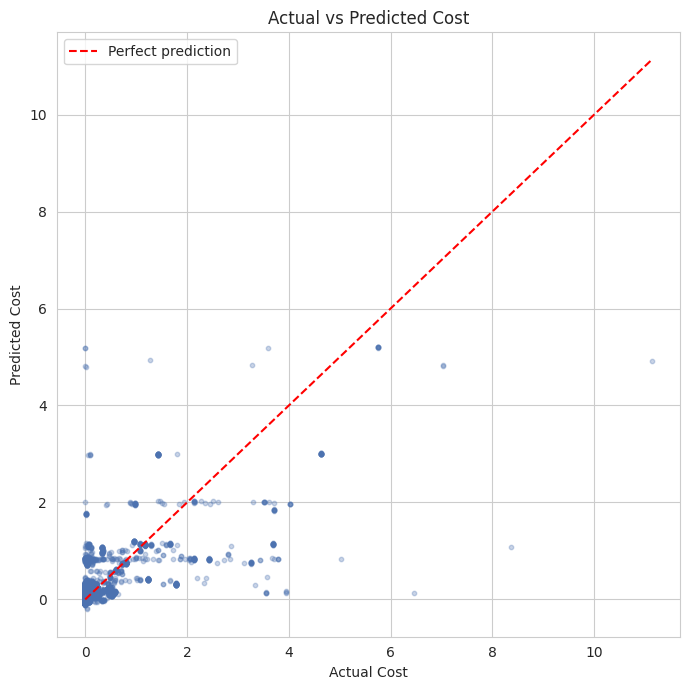

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='#4C72B0')
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Cost')
plt.ylabel('Predicted Cost')
plt.title('Actual vs Predicted Cost')
plt.legend()
plt.tight_layout()
plt.savefig('../images/09_actual_vs_predicted.png', dpi=100)
plt.show()


**Interpretation:** With `R²` in the range shown above, a single global Linear Regression model captures a meaningful share of cost variance, but cloud cost data is highly non-linear (a handful of very expensive services dominate the tail). This is expected and documented as a known limitation — the README notes that tree-based models (Random Forest / Gradient Boosting) would likely outperform this baseline, to be explored in a v2 of the project.

## Step 13: Save Model

In [25]:
import os
os.makedirs('../models', exist_ok=True)

with open('../models/linear_regression_pipeline.pkl', 'wb') as f:
    pickle.dump(model_pipeline, f)

# Save the exact column lists/order the Streamlit app must supply
feature_schema = {
    'numeric_features': numeric_features,
    'onehot_features': onehot_features,
    'ordinal_features': ordinal_features,
    'all_features_in_order': numeric_features + onehot_features + ordinal_features,
}
with open('../models/feature_schema.pkl', 'wb') as f:
    pickle.dump(feature_schema, f)

# Save category options (for populating Streamlit dropdowns with real, known values)
category_options = {col: sorted(df_model[col].dropna().unique().tolist()) for col in onehot_features + ordinal_features}
with open('../models/category_options.pkl', 'wb') as f:
    pickle.dump(category_options, f)

print("Saved: linear_regression_pipeline.pkl, feature_schema.pkl, category_options.pkl")


Saved: linear_regression_pipeline.pkl, feature_schema.pkl, category_options.pkl


## Step 14: Streamlit Application

See `app.py` in the project root. It loads `linear_regression_pipeline.pkl` (which bundles the scaler + encoders + model into one object), builds a form matching `feature_schema.pkl`, and outputs the predicted cost — without any risk of column-order mismatch, because the same `Pipeline` object does the transform in both notebook and app.

## Conclusion

| Metric | Value |
|---|---|
| Rows used for training | see `X_train.shape` above |
| Model | Linear Regression (scikit-learn Pipeline) |
| MAE | printed above |
| RMSE | printed above |
| R² | printed above |

**Skills demonstrated:** Business problem framing, EDA, data cleaning, feature engineering, categorical encoding (one-hot + ordinal), feature scaling, Linear Regression, model evaluation, model serialization, and Streamlit deployment.
